This notebook refits QUEST to random subsets of trials, and asks how the crowding vs. RSVP correlation changes with the noise ceiling.

Input (from `extract_trials_level_response.ipynb`):
- `tidy_both_sessions_trials_level_response.csv`
- `tidy_both_sessions_staircases_quest_params.csv`

Steps:
1. Rebuild each staircase's QUEST posterior and check that the posterior mean matches EasyEyes' `questMeanAtEndOfTrialsLoop`.
2. For each number of trials k, randomly pick k trials (without replacement) from every staircase and refit QUEST. Repeat `n_draws` times.
3. For each pair (k crowding, k RSVP) and each draw: reliability of each task (split-half + Spearman-Brown), noise ceiling = sqrt(rel_crowding * rel_rsvp), measured r, and corrected r = measured r / noise ceiling.
4. Plot correlation against the noise ceiling.

Results are saved to `subsample_corr_crowding_rsvp.csv`, so the plot can be remade without refitting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
# settings
n_draws = 200
seed = 2026
quest_range = 5  # width (log units) of QUEST's grid of candidate thresholds; the jsQUEST default, validated below

# number of trials sampled from each staircase; np.inf = all trials
k_grid = {'crowding': [2, 3, 5, 8, 12, 16, 20, 25, 30, np.inf],  # letter trials (about 35 per staircase)
          'rsvp':     [3, 6, 9, 15, 21, 30, 40, 50, 60, np.inf]}  # single words (about 70 per staircase)

# staircases per participant, as columns of repeats.
# The order sets the split halves: first/last half = session 1 vs. session 2; odd/even = L8 vs. R8.
columns = {'crowding': ['crowding_R8_block1', 'crowding_L8_block1', 'crowding_R8_block2', 'crowding_L8_block2',
                        'crowding_R8_block3', 'crowding_L8_block3', 'crowding_R8_block4', 'crowding_L8_block4'],
           'rsvp': ['rsvp_foveal_block1', 'rsvp_foveal_block2']}

output_path = 'subsample_corr_crowding_rsvp.csv'

# Import data

In [3]:
trials = pd.read_csv('tidy_both_sessions_trials_level_response.csv')
staircases = pd.read_csv('tidy_both_sessions_staircases_quest_params.csv')
staircases = staircases[staircases['nTrials'] > 0].reset_index(drop=True)

# QUEST
Same computation as QuestCreate, QuestUpdate and QuestMean (Watson & Pelli, 1983, *Perception & Psychophysics* 33:113-120; jsQUEST in EasyEyes):
- Prior: Gaussian over log threshold, mean tGuess, SD tGuessSd, on a grid with step `grain`.
- Psychometric function (Weibull): P(correct) = delta*gamma + (1-delta) * (1 - (1-gamma) * exp(-10^(beta * (level - threshold + xThreshold)))). xThreshold makes P(correct) = pThreshold when level = threshold.
- Estimate: posterior mean.

Because the posterior is the prior times the likelihood of each response, the order of trials does not matter, so a random subset can be fit directly.

In [4]:
def quest_grid(st, quest_range=5):
    """Candidate thresholds (log units) and log prior, as in QuestCreate."""
    dim = int(2 * np.ceil(quest_range / st.grain / 2))
    x = np.arange(-dim // 2, dim // 2 + 1) * st.grain
    return st.tGuess + x, -0.5 * (x / st.tGuessSd) ** 2, dim


def quest_loglik(st, levels, responses, quest_range=5):
    """
    Log likelihood of each response (rows) at each candidate threshold (columns).
    As in QuestUpdate, the level is rounded to the grid, and level - threshold is limited to the table range.
    """
    t, _, dim = quest_grid(st, quest_range)
    xThreshold = np.log10(-np.log((1 - (st.pThreshold - st.delta * st.gamma) / (1 - st.delta)) / (1 - st.gamma))) / st.beta
    levels = st.tGuess + st.grain * np.round((np.asarray(levels) - st.tGuess) / st.grain)
    d = np.clip(levels[:, None] - t[None, :], -dim * st.grain, dim * st.grain)
    p = st.delta * st.gamma + (1 - st.delta) * (1 - (1 - st.gamma) * np.exp(-10 ** (st.beta * (d + xThreshold))))
    return np.where(np.asarray(responses)[:, None] == 1, np.log(p), np.log(1 - p))


def quest_mean(t, log_posterior):
    """Posterior mean (QuestMean). log_posterior can be 1-D, or 2-D with one row per draw."""
    w = np.exp(log_posterior - log_posterior.max(axis=-1, keepdims=True))
    return (w * t).sum(axis=-1) / w.sum(axis=-1)

In [5]:
# build the likelihood table of every staircase once
trials_by_staircase = dict(tuple(trials.groupby(['prolificID', 'conditionName'])))
quest_tables = {}
for st in staircases.itertuples():
    g = trials_by_staircase[(st.prolificID, st.conditionName)]
    t, log_prior, _ = quest_grid(st, quest_range)
    quest_tables[(st.prolificID, st.conditionName)] = (t, log_prior, quest_loglik(st, g['level'], g['response'], quest_range))

In [6]:
# validation: refit with all trials and compare with EasyEyes' final QUEST mean
staircases['refit_all_trials'] = [quest_mean(t, log_prior + L.sum(axis=0))
                                  for t, log_prior, L in (quest_tables[key] for key in zip(staircases['prolificID'], staircases['conditionName']))]
refit_error = (staircases['refit_all_trials'] - staircases['questMeanAtEnd']).abs()

print('Largest |refit - questMeanAtEndOfTrialsLoop| (log units):')
print(refit_error.groupby(staircases['taskName']).max())
assert refit_error.max() < 1e-3, 'Fatal: QUEST refit does not match EasyEyes'

Largest |refit - questMeanAtEndOfTrialsLoop| (log units):
taskName
acuity      0.000002
crowding    0.000002
rsvp        0.000010
dtype: float64


# Data cleaning

In [7]:
# exclude participants, per task
with open('exclude_dict.json', 'r') as f:
    exclude_dict = json.load(f)

for task, exclude_ids in exclude_dict.items():
    staircases = staircases[~((staircases['taskName'] == task) & (staircases['prolificID'].isin(exclude_ids)))]

# keep participants who have every crowding and RSVP staircase, so the sample is the same for every k
all_columns = columns['crowding'] + columns['rsvp']
n_staircases = staircases[staircases['conditionName'].isin(all_columns)].groupby('prolificID')['conditionName'].nunique()
subjects = np.sort(n_staircases[n_staircases == len(all_columns)].index.to_numpy())

print(f'Number of participants with all {len(all_columns)} crowding and RSVP staircases: {len(subjects)}')

Number of participants with all 10 crowding and RSVP staircases: 93


# Subsample trials and refit

In [8]:
def subsample_thresholds(task, rng):
    """
    Refit QUEST to k randomly chosen trials (without replacement) from each staircase.
    Within a draw, the subsets are nested across k (the trials for k=5 are among the trials for k=8).
    Returns
      thresholds: shape (len(k_grid[task]), n_draws, n_subjects, n_columns)
      n_short: for each k, the number of staircases with fewer than k trials (all of their trials were used)
    """
    ks = k_grid[task]
    thresholds = np.full((len(ks), n_draws, len(subjects), len(columns[task])), np.nan)
    n_short = np.zeros(len(ks), dtype=int)

    for s, prolificID in enumerate(subjects):
        for c, condition_name in enumerate(columns[task]):
            t, log_prior, L = quest_tables[(prolificID, condition_name)]
            n = L.shape[0]
            trial_rank = rng.random((n_draws, n)).argsort(axis=1).argsort(axis=1)  # random order of trials, per draw
            for i, k in enumerate(ks):
                chosen = (trial_rank < k).astype(float)
                thresholds[i, :, s, c] = quest_mean(t, log_prior + chosen @ L)
                n_short[i] += np.isfinite(k) and n < k

    return thresholds, n_short

In [9]:
rng = np.random.default_rng(seed)
thresholds = {}
for task in ['crowding', 'rsvp']:
    thresholds[task], n_short = subsample_thresholds(task, rng)
    print(f'{task}: staircases with fewer than k trials, per k {k_grid[task]}: {n_short.tolist()}')

# RSVP: log10(sec per word) -> log10(words per min), as in extract_thresholds_per_trial
thresholds['rsvp'] = np.log10(60) - thresholds['rsvp']

crowding: staircases with fewer than k trials, per k [2, 3, 5, 8, 12, 16, 20, 25, 30, inf]: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


rsvp: staircases with fewer than k trials, per k [3, 6, 9, 15, 21, 30, 40, 50, 60, inf]: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


# Reliability and correlation

In [10]:
def pearson_r(a, b):
    """Pearson r along the last axis."""
    a = a - a.mean(axis=-1, keepdims=True)
    b = b - b.mean(axis=-1, keepdims=True)
    return (a * b).sum(axis=-1) / np.sqrt((a * a).sum(axis=-1) * (b * b).sum(axis=-1))


def split_half_reliability(X):
    """
    Same method as summarize_task in analysis_from_tidy_per_trial:
    split-half r for first/last half and for odd/even columns, geometric mean, then Spearman-Brown.
    X has shape (..., n_subjects, n_columns). Returns reliability with shape (...),
    and a boolean array marking where a split-half r was negative.
    """
    n = X.shape[-1]
    r_FL = pearson_r(X[..., :n // 2].mean(axis=-1), X[..., n // 2:].mean(axis=-1))
    r_OE = pearson_r(X[..., 1::2].mean(axis=-1), X[..., 0::2].mean(axis=-1))

    # as in summarize_task: if a split-half r is negative, take absolute values
    negative = (r_FL < 0) | (r_OE < 0)
    r_i = np.clip(np.sqrt(np.abs(r_FL) * np.abs(r_OE)), 0.0, 0.999999)
    return 2 * r_i / (1 + r_i), negative

In [11]:
reliability = {}
for task in ['crowding', 'rsvp']:
    reliability[task], negative = split_half_reliability(thresholds[task])  # shape (n_k, n_draws)
    print(f'{task}: draws with a negative split-half r, per k: {negative.sum(axis=1).tolist()}')

# per participant: mean over all staircases of a task
x = thresholds['crowding'].mean(axis=-1)  # (n_k crowding, n_draws, n_subjects)
y = thresholds['rsvp'].mean(axis=-1)      # (n_k rsvp, n_draws, n_subjects)

zx = (x - x.mean(axis=-1, keepdims=True)) / x.std(axis=-1, keepdims=True)
zy = (y - y.mean(axis=-1, keepdims=True)) / y.std(axis=-1, keepdims=True)
r_measured = np.einsum('ids,jds->ijd', zx, zy) / len(subjects)  # (n_k crowding, n_k rsvp, n_draws)

r_ceiling = np.sqrt(reliability['crowding'][:, None, :] * reliability['rsvp'][None, :, :])
r_corrected = r_measured / r_ceiling

crowding: draws with a negative split-half r, per k: [79, 46, 4, 0, 0, 0, 0, 0, 0, 0]
rsvp: draws with a negative split-half r, per k: [33, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [12]:
# long form: one row per (k crowding, k rsvp, draw)
i, j, d = np.meshgrid(np.arange(len(k_grid['crowding'])), np.arange(len(k_grid['rsvp'])), np.arange(n_draws), indexing='ij')
results = pd.DataFrame({'k_crowding': np.array(k_grid['crowding'])[i.ravel()],
                        'k_rsvp': np.array(k_grid['rsvp'])[j.ravel()],
                        'draw': d.ravel(),
                        'rel_crowding': reliability['crowding'][i.ravel(), d.ravel()],
                        'rel_rsvp': reliability['rsvp'][j.ravel(), d.ravel()],
                        'r_ceiling': r_ceiling.ravel(),
                        'r_measured': r_measured.ravel(),
                        'r_corrected': r_corrected.ravel()})
results['n_subjects'] = len(subjects)
results.to_csv(output_path, index=False)

In [13]:
def summarize_draws(results):
    """
    One row per (k crowding, k rsvp): median and 25th/75th percentiles across draws.
    Medians are used because corrected r = r / ceiling has extreme values when a draw's ceiling is near 0.
    """
    stats_cols = ['rel_crowding', 'rel_rsvp', 'r_ceiling', 'r_measured', 'r_corrected']
    g = results.groupby(['k_crowding', 'k_rsvp'])[stats_cols]
    summary = g.median()
    for q in [0.25, 0.75]:
        summary = summary.join(g.quantile(q)[['r_measured', 'r_corrected']].add_suffix(f'_q{int(q * 100)}'))
    return summary.reset_index()


display(summarize_draws(results).round(3))

,k_crowding,k_rsvp,rel_crowding,rel_rsvp,r_ceiling,r_measured,r_corrected,r_measured_q25,r_corrected_q25,r_measured_q75,r_corrected_q75
0,2.0,3.0,0.153,0.174,0.145,-0.074,-0.491,-0.145,-1.029,-0.013,-0.086
1,2.0,6.0,0.153,0.441,0.250,-0.106,-0.407,-0.161,-0.681,-0.037,-0.146
2,2.0,9.0,0.153,0.645,0.308,-0.111,-0.433,-0.194,-0.644,-0.071,-0.203
3,2.0,15.0,0.153,0.794,0.342,-0.133,-0.420,-0.191,-0.635,-0.081,-0.211
4,2.0,21.0,0.153,0.851,0.360,-0.139,-0.385,-0.188,-0.627,-0.085,-0.233
...,...,...,...,...,...,...,...,...,...,...,...
95,inf,30.0,0.877,0.887,0.882,-0.392,-0.445,-0.405,-0.459,-0.378,-0.428
96,inf,40.0,0.877,0.905,0.891,-0.401,-0.449,-0.411,-0.462,-0.389,-0.438
97,inf,50.0,0.877,0.913,0.895,-0.404,-0.451,-0.411,-0.459,-0.396,-0.443
98,inf,60.0,0.877,0.919,0.898,-0.405,-0.451,-0.410,-0.457,-0.401,-0.447


# Visualization
The y axis is correlation strength, -r (crowding distance and RSVP reading speed are negatively correlated).
Each dot is one (k crowding, k RSVP) pair: the median across draws.
The pairs are grouped into equal-width bins of the noise ceiling. In each bin, the line is the mean of the dots, and the shaded area spans the mean 25th to the mean 75th percentile across draws.
The ringed dots use all trials.

In [14]:
def plot_corr_vs_ceiling(summary, n_bins=8, title='Crowding vs. RSVP reading speed'):

    series = {'r_measured': ('Measured r', '#2a78d6'),
              'r_corrected': ('Corrected r', '#eb6834')}
    bins = np.linspace(summary['r_ceiling'].min(), summary['r_ceiling'].max(), n_bins + 1)
    ceiling_bin = pd.cut(summary['r_ceiling'], bins, include_lowest=True)
    all_trials = summary[np.isinf(summary['k_crowding']) & np.isinf(summary['k_rsvp'])].iloc[0]

    fig, ax = plt.subplots(figsize=(6, 4.5))

    for col, (label, color) in series.items():
        # plot correlation strength, -r; the 75th percentile of r becomes the lower edge of -r
        strength = summary.assign(y=-summary[col], lo=-summary[f'{col}_q75'], hi=-summary[f'{col}_q25'])
        binned = strength.groupby(ceiling_bin, observed=True).agg(x=('r_ceiling', 'mean'), y=('y', 'mean'),
                                                                 lo=('lo', 'mean'), hi=('hi', 'mean'))
        ax.fill_between(binned['x'], binned['lo'], binned['hi'], color=color, alpha=0.2, lw=0)
        ax.scatter(strength['r_ceiling'], strength['y'], s=25, color=color, alpha=0.5, lw=0)
        ax.plot(binned['x'], binned['y'], color=color, lw=2, label=label)
        ax.scatter(all_trials['r_ceiling'], -all_trials[col], s=90, facecolor='none', edgecolor='#0b0b0b', lw=1.2, zorder=3)

    ax.annotate('all trials', (all_trials['r_ceiling'], -all_trials['r_measured']),
                xytext=(0, -18), textcoords='offset points', ha='center', fontsize=9, color='#52514e')
    ax.set_ylim(0, 1)
    ax.set_xlabel(r'Noise ceiling, $\sqrt{rel_{crowding} \cdot rel_{RSVP}}$')
    ax.set_ylabel('Correlation strength, $-r$')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()
    plt.show()

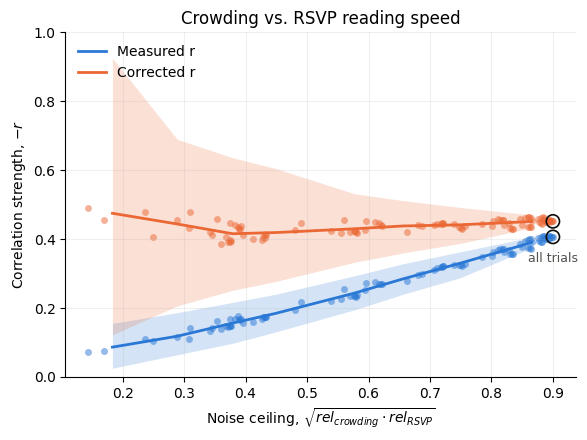

In [15]:
plot_corr_vs_ceiling(summarize_draws(pd.read_csv(output_path)))